In [12]:
import numpy as np
import pandas as pd

In [18]:
df = pd.read_csv('Social_Network_Ads.csv')

In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [20]:
df = df[['Age', 'EstimatedSalary','Purchased']]

In [21]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [22]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [30]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [25]:
x_scaled

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [28]:
x_train.shape

(320, 2)

In [31]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [36]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [37]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 10)                30        
                                                                 
 dense_10 (Dense)            (None, 10)                110       
                                                                 
 dense_11 (Dense)            (None, 1)                 11        
                                                                 
Total params: 151
Trainable params: 151
Non-trainable params: 0
_________________________________________________________________


In [39]:
import time

In [44]:
# Batch Gradient descent
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(x_train,y_train,epochs=10,batch_size=320)
print(time.time()-start)

Epoch 1/10
1/1 [==============================] - 0s 401ms/step - loss: 57.1204 - accuracy: 0.3469
Epoch 2/10
1/1 [==============================] - 0s 9ms/step - loss: 55.6703 - accuracy: 0.6531
Epoch 3/10
1/1 [==============================] - 0s 11ms/step - loss: 7.0242 - accuracy: 0.3469
Epoch 4/10
1/1 [==============================] - 0s 9ms/step - loss: 58.5806 - accuracy: 0.6531
Epoch 5/10
1/1 [==============================] - 0s 13ms/step - loss: 12.4559 - accuracy: 0.6531
Epoch 6/10
1/1 [==============================] - 0s 10ms/step - loss: 40.8167 - accuracy: 0.3469
Epoch 7/10
1/1 [==============================] - 0s 8ms/step - loss: 20.2336 - accuracy: 0.6531
Epoch 8/10
1/1 [==============================] - 0s 7ms/step - loss: 22.2276 - accuracy: 0.3469
Epoch 9/10
1/1 [==============================] - 0s 7ms/step - loss: 28.9925 - accuracy: 0.6531
Epoch 10/10
1/1 [==============================] - 0s 6ms/step - loss: 6.4388 - accuracy: 0.3531
0.5971136093139648


In [45]:
# Stochastic Gradient descent
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(x_train,y_train,epochs=10,batch_size=1)
print(time.time()-start)

Epoch 1/10
320/320 [==============================] - 2s 4ms/step - loss: 26.3245 - accuracy: 0.5594
Epoch 2/10
320/320 [==============================] - 2s 5ms/step - loss: 29.4043 - accuracy: 0.5031
Epoch 3/10
320/320 [==============================] - 2s 5ms/step - loss: 25.7070 - accuracy: 0.5594
Epoch 4/10
320/320 [==============================] - 1s 4ms/step - loss: 26.1107 - accuracy: 0.5000
Epoch 5/10
320/320 [==============================] - 1s 4ms/step - loss: 23.7421 - accuracy: 0.5437
Epoch 6/10
320/320 [==============================] - 1s 4ms/step - loss: 23.4458 - accuracy: 0.5156
Epoch 7/10
320/320 [==============================] - 1s 4ms/step - loss: 19.3541 - accuracy: 0.5625
Epoch 8/10
320/320 [==============================] - 1s 4ms/step - loss: 18.5033 - accuracy: 0.5656
Epoch 9/10
320/320 [==============================] - 1s 4ms/step - loss: 19.3031 - accuracy: 0.4906
Epoch 10/10
320/320 [==============================] - 1s 4ms/step - loss: 16.6110 - accura

# Lets check which model converge faster

In [64]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [65]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [67]:
X_scaled.shape

(400, 2)

In [ ]:
# 400 will be batch size for batch gd

In [68]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [69]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [70]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 10)                30        
                                                                 
 dense_16 (Dense)            (None, 10)                110       
                                                                 
 dense_17 (Dense)            (None, 1)                 11        
                                                                 
Total params: 151
Trainable params: 151
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Batch GD
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)

Epoch 1/500
1/1 [==============================] - 1s 951ms/step - loss: 0.6785 - accuracy: 0.5562 - val_loss: 0.6376 - val_accuracy: 0.6500
Epoch 2/500
1/1 [==============================] - 0s 62ms/step - loss: 0.6711 - accuracy: 0.6156 - val_loss: 0.6378 - val_accuracy: 0.6625
Epoch 3/500
1/1 [==============================] - 0s 52ms/step - loss: 0.6659 - accuracy: 0.6469 - val_loss: 0.6380 - val_accuracy: 0.6750
Epoch 4/500
1/1 [==============================] - 0s 39ms/step - loss: 0.6616 - accuracy: 0.6812 - val_loss: 0.6380 - val_accuracy: 0.6875
Epoch 5/500
1/1 [==============================] - 0s 40ms/step - loss: 0.6578 - accuracy: 0.6875 - val_loss: 0.6381 - val_accuracy: 0.6750
Epoch 6/500
1/1 [==============================] - 0s 39ms/step - loss: 0.6543 - accuracy: 0.7125 - val_loss: 0.6381 - val_accuracy: 0.7125
Epoch 7/500
1/1 [==============================] - 0s 42ms/step - loss: 0.6510 - accuracy: 0.7281 - val_loss: 0.6381 - val_accuracy: 0.7500
Epoch 8/500
1/1 [==

In [ ]:
# Stochastic GD
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=10,batch_size=1,validation_split=0.2)

Epoch 1/10
320/320 [==============================] - 2s 5ms/step - loss: 0.2453 - accuracy: 0.9031 - val_loss: 0.1564 - val_accuracy: 0.9875
Epoch 2/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2535 - accuracy: 0.9031 - val_loss: 0.1567 - val_accuracy: 0.9750
Epoch 3/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2514 - accuracy: 0.9031 - val_loss: 0.1612 - val_accuracy: 0.9625
Epoch 4/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2526 - accuracy: 0.9031 - val_loss: 0.1529 - val_accuracy: 0.9875
Epoch 5/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2536 - accuracy: 0.9094 - val_loss: 0.1505 - val_accuracy: 0.9875
Epoch 6/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2563 - accuracy: 0.9062 - val_loss: 0.1676 - val_accuracy: 0.9250
Epoch 7/10
320/320 [==============================] - 1s 4ms/step - loss: 0.2542 - accuracy: 0.9031 - val_loss: 0.1604 - val_accuracy: 0.9625
Epoch 

# Loss function Reduction

In [58]:
# Batch GD
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)

Epoch 1/500
1/1 [==============================] - 1s 610ms/step - loss: 0.2513 - accuracy: 0.9094 - val_loss: 0.1757 - val_accuracy: 0.9250
Epoch 2/500
1/1 [==============================] - 0s 42ms/step - loss: 0.2486 - accuracy: 0.9094 - val_loss: 0.1793 - val_accuracy: 0.9250
Epoch 3/500
1/1 [==============================] - 0s 37ms/step - loss: 0.2468 - accuracy: 0.9094 - val_loss: 0.1822 - val_accuracy: 0.9250
Epoch 4/500
1/1 [==============================] - 0s 37ms/step - loss: 0.2454 - accuracy: 0.9125 - val_loss: 0.1848 - val_accuracy: 0.9250
Epoch 5/500
1/1 [==============================] - 0s 38ms/step - loss: 0.2443 - accuracy: 0.9125 - val_loss: 0.1870 - val_accuracy: 0.9250
Epoch 6/500
1/1 [==============================] - 0s 35ms/step - loss: 0.2432 - accuracy: 0.9125 - val_loss: 0.1887 - val_accuracy: 0.9250
Epoch 7/500
1/1 [==============================] - 0s 45ms/step - loss: 0.2422 - accuracy: 0.9125 - val_loss: 0.1905 - val_accuracy: 0.9250
Epoch 8/500
1/1 [==

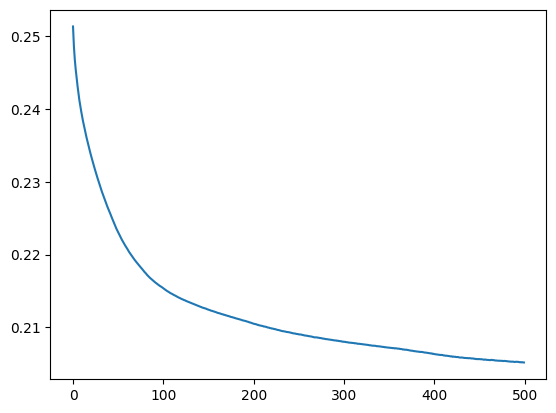

In [60]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [ ]:
# Smooth loss function reduction in batch GD

In [71]:
# Stochastic GD
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
history = model.fit(X_scaled,y,epochs=500,batch_size=1,validation_split=0.2)

Epoch 1/500
320/320 [==============================] - 2s 5ms/step - loss: 0.4811 - accuracy: 0.8094 - val_loss: 0.6467 - val_accuracy: 0.6250
Epoch 2/500
320/320 [==============================] - 1s 4ms/step - loss: 0.3490 - accuracy: 0.8344 - val_loss: 0.5968 - val_accuracy: 0.6750
Epoch 3/500
320/320 [==============================] - 2s 5ms/step - loss: 0.3245 - accuracy: 0.8344 - val_loss: 0.5433 - val_accuracy: 0.6750
Epoch 4/500
320/320 [==============================] - 1s 4ms/step - loss: 0.3148 - accuracy: 0.8375 - val_loss: 0.5093 - val_accuracy: 0.6750
Epoch 5/500
320/320 [==============================] - 1s 4ms/step - loss: 0.3069 - accuracy: 0.8438 - val_loss: 0.4649 - val_accuracy: 0.6750
Epoch 6/500
320/320 [==============================] - 1s 4ms/step - loss: 0.2971 - accuracy: 0.8406 - val_loss: 0.4319 - val_accuracy: 0.7250
Epoch 7/500
320/320 [==============================] - 1s 4ms/step - loss: 0.2909 - accuracy: 0.8531 - val_loss: 0.4061 - val_accuracy: 0.7500

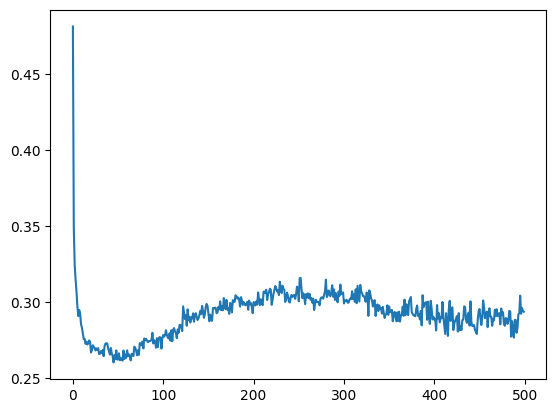

In [72]:
plt.plot(history.history['loss'])